# BraTS 2024 to NPZ Conversion and Visualization

This notebook converts the BraTS 2024 challenge datasets into a unified `.npz` format for testing. It supports both:
- **BraTS-GLI**: Adult glioma post-treatment (MRI sequences: t1c, t1n, t2f, t2w).
- **BraTS-MEN-RT**: Meningioma radiotherapy planning (MRI sequence: t1c).

In [1]:
import sys
from pathlib import Path
import os
import numpy as np

parent = Path().resolve().parent.parent 
sys.path.append(str(parent))

from data.test_data.brats_to_npz import process_brats_gli, process_brats_men_rt
from data.DataLoader_npz import DataLoader_npz
from data.DataGenerator import DataGenerator
from utils.visualization import visualize_img_with_mask, plot_vol_slices, plot_one_dp

## 1. Process BraTS-GLI Dataset

Processing the glioma dataset. By default, we use the `t1c` sequence.

In [ ]:
data_dir_gli = "BraTS_2024/BraTS-GLI"
sequences = ["t1c", "t1n", "t2f", "t2w"]

for sequence in sequences:
    output_gli = f"BraTS_GLI_{sequence}"

    if os.path.exists(data_dir_gli):
        process_brats_gli(
            data_dir=data_dir_gli, 
            output_path=output_gli, 
            sequence=sequence,
            resample=True
        )
    else:
        print(f"Directory {data_dir_gli} not found.")

## 2. Process BraTS-MEN-RT Dataset

Processing the meningioma radiotherapy dataset. Note that this data is in native space and will be resampled to 1.0mm isotropic.

In [ ]:
data_dir_men = "BraTS_2024/BraTS-MEN-RT"
output_men = "BraTS_MEN_RT"

if os.path.exists(data_dir_men):
    process_brats_men_rt(
        data_dir=data_dir_men, 
        output_path=output_men, 
        resample=True
    )
else:
    print(f"Directory {data_dir_men} not found.")

## 3. Load and Visualize Results

Now we load the generated `.npz` file and visualize a few samples.

### BraTS_GLI

In [ ]:
# sequences = ["t1c", "t1n", "t2f", "t2w"]

In [ ]:
npz_path = f"data/test_data/BraTS_GLI_t1c.npz"

dg = DataGenerator(DataLoader_npz([npz_path], val_size=0.0))
all_ids = dg.dataloader.train_ids
print(f"Loaded IDs: {all_ids}")

sample_id = all_ids[0]
img = dg.dataloader.dataset[sample_id]['image']
mask = dg.dataloader.dataset[sample_id]['segmentations']

print(f"Sample: {sample_id}")
print(f"Image shape: {img.shape}")
print(f"Mask shape: {mask[0].shape}")


Loading NPZ dataset(s)…
Loaded 271 PIDs from C:\Users\Paul\Desktop\Studium\prompt-unet\data\test_data\BraTS_GLI_t2w.npz

Final dataset size: 271 patients.

Loaded IDs: ['BraTS_GLI_t2w_BraTS-GLI-02492-104', 'BraTS_GLI_t2w_BraTS-GLI-02597-102', 'BraTS_GLI_t2w_BraTS-GLI-02646-101', 'BraTS_GLI_t2w_BraTS-GLI-02592-101', 'BraTS_GLI_t2w_BraTS-GLI-02502-100', 'BraTS_GLI_t2w_BraTS-GLI-02565-100', 'BraTS_GLI_t2w_BraTS-GLI-02506-101', 'BraTS_GLI_t2w_BraTS-GLI-02571-102', 'BraTS_GLI_t2w_BraTS-GLI-02418-101', 'BraTS_GLI_t2w_BraTS-GLI-02643-101', 'BraTS_GLI_t2w_BraTS-GLI-02512-101', 'BraTS_GLI_t2w_BraTS-GLI-02639-100', 'BraTS_GLI_t2w_BraTS-GLI-02510-101', 'BraTS_GLI_t2w_BraTS-GLI-02591-101', 'BraTS_GLI_t2w_BraTS-GLI-02564-102', 'BraTS_GLI_t2w_BraTS-GLI-02503-100', 'BraTS_GLI_t2w_BraTS-GLI-02570-104', 'BraTS_GLI_t2w_BraTS-GLI-02507-100', 'BraTS_GLI_t2w_BraTS-GLI-02570-102', 'BraTS_GLI_t2w_BraTS-GLI-02619-100', 'BraTS_GLI_t2w_BraTS-GLI-02562-101', 'BraTS_GLI_t2w_BraTS-GLI-02485-100', 'BraTS_GLI_t2w_B

### Interactive Visualization

Note: This interactive view will not be saved when you restart the notebook.

In [ ]:
visualize_img_with_mask(img, mask[0]) # t1c

interactive(children=(IntSlider(value=24, description='Slice:', max=48), Output()), _dom_classes=('widget-inte…

### Static Persistent Visualization

This grid view is saved in the notebook, so you can see it later even without a running kernel.

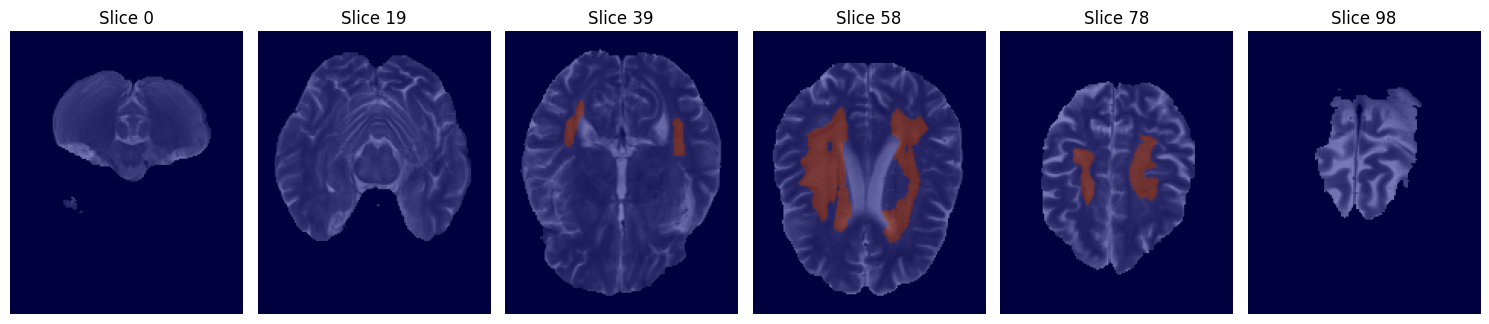

In [ ]:
plot_vol_slices(img, mask[0], num_slices=6) #t2w

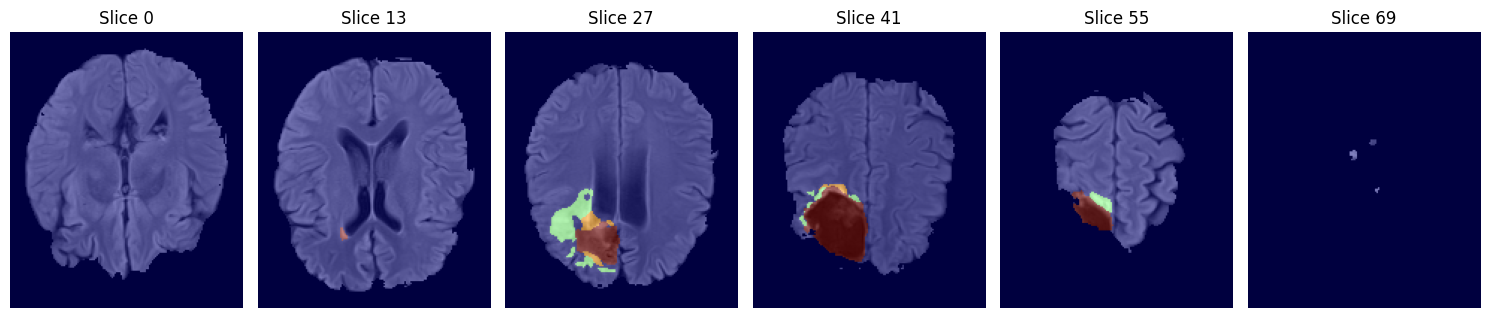

In [ ]:
plot_vol_slices(img, mask[0], num_slices=6) #t2f

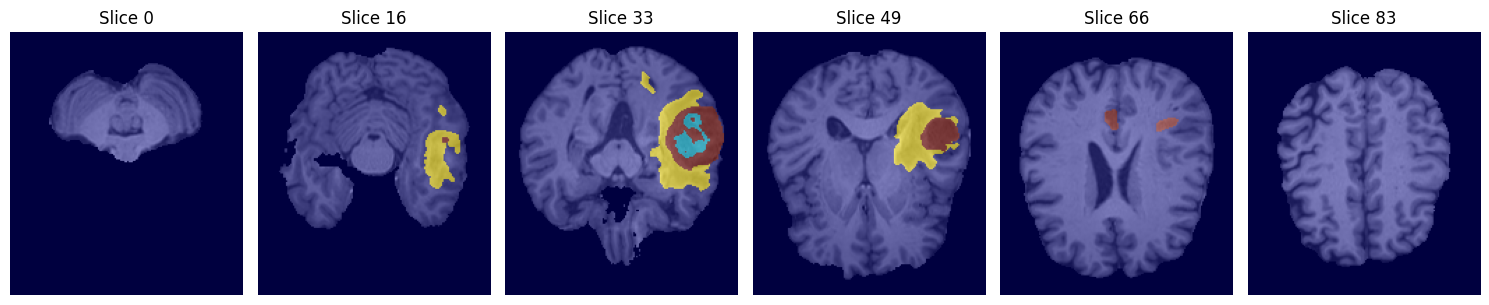

In [ ]:
plot_vol_slices(img, mask[0], num_slices=6) #t1n

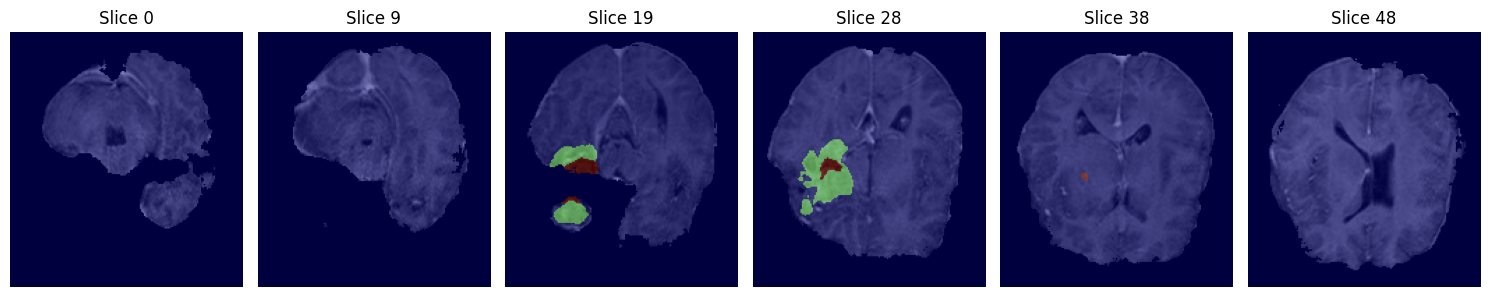

In [ ]:
plot_vol_slices(img, mask[0], num_slices=6) # t1c

In [6]:
x_np, y_np, p_np, m_np, offset_list = dg.get_data_points_numpy(max_data_points=100, offset=10, max_number_labels=3)

Creating new Data Points ...
It took 0 seconds


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.0..2.612417].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.0..2.612417].


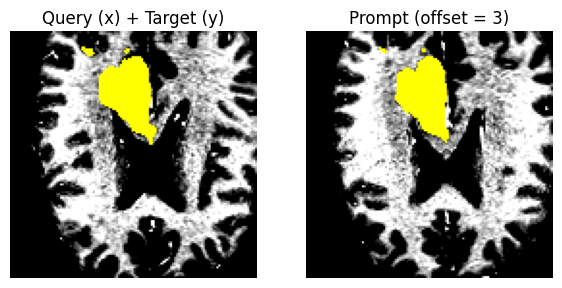

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.0..2.612417].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.0..2.612417].



x: -5.0 - 2.612416982650757 | y: 0.0 - 1.0 | p (img): -5.0 - 2.612416982650757 | p (roi): 0.0 - 1.0
[0. 1.] [0. 1.]
float32 float32 float32 float32


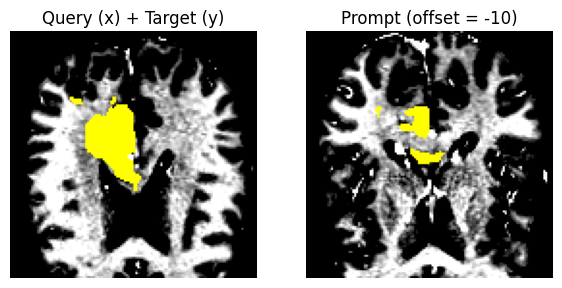

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.0..2.612417].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.0..2.612417].



x: -5.0 - 2.612416982650757 | y: 0.0 - 1.0 | p (img): -5.0 - 2.612416982650757 | p (roi): 0.0 - 1.0
[0. 1.] [0. 1.]
float32 float32 float32 float32


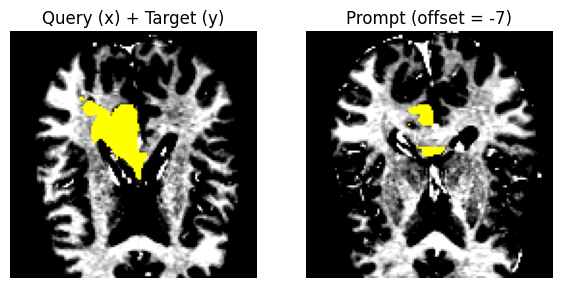

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.0..2.612417].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.0..2.612417].



x: -5.0 - 2.612416982650757 | y: 0.0 - 1.0 | p (img): -5.0 - 2.612416982650757 | p (roi): 0.0 - 1.0
[0. 1.] [0. 1.]
float32 float32 float32 float32


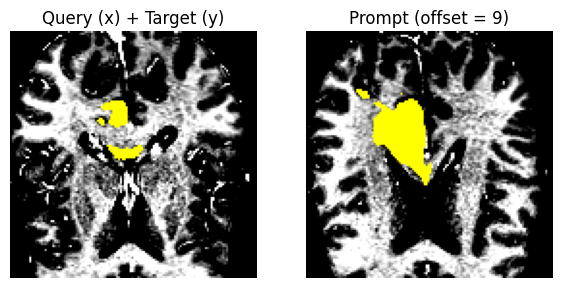

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.0..2.612417].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.0..2.612417].



x: -5.0 - 2.612416982650757 | y: 0.0 - 1.0 | p (img): -5.0 - 2.612416982650757 | p (roi): 0.0 - 1.0
[0. 1.] [0. 1.]
float32 float32 float32 float32


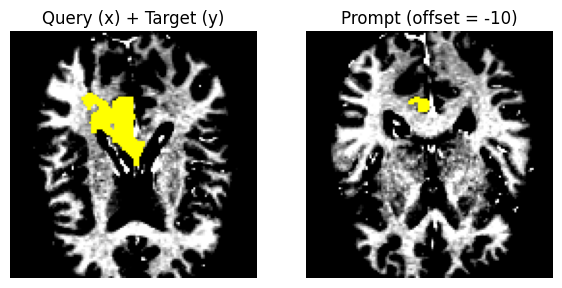

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.0..2.612417].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.0..2.612417].



x: -5.0 - 2.612416982650757 | y: 0.0 - 1.0 | p (img): -5.0 - 2.612416982650757 | p (roi): 0.0 - 1.0
[0. 1.] [0. 1.]
float32 float32 float32 float32


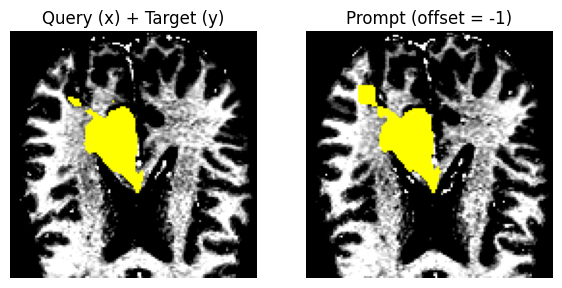


x: -5.0 - 2.612416982650757 | y: 0.0 - 1.0 | p (img): -5.0 - 2.612416982650757 | p (roi): 0.0 - 1.0
[0. 1.] [0. 1.]
float32 float32 float32 float32


In [7]:
for dp_idx in range(x_np.shape[0]):
    x, y, p = x_np[dp_idx,...], y_np[dp_idx,...], p_np[dp_idx,...]
    plot_one_dp(x,y,p, offset_list[dp_idx])
    print(f'x: {np.min(x)} - {np.max(x)} | y: {np.min(y)} - {np.max(y)} | p (img): {np.min(p[...,0])} - {np.max(p[...,0])} | p (roi): {np.min(p[...,1])} - {np.max(p[...,1])}')
    print(np.unique(y), np.unique(p[...,1]))
    print(x.dtype, y.dtype, p[...,0].dtype, p[...,1].dtype)
    if dp_idx == 5:
        break

### BraTS-MEN-RT

In [3]:
npz_path = f"data/test_data/BraTS_MEN_RT.npz"

dg = DataGenerator(DataLoader_npz([npz_path], val_size=0.0))
all_ids = dg.dataloader.train_ids
print(f"Loaded IDs: {all_ids}")

sample_id = all_ids[0]
img = dg.dataloader.dataset[sample_id]['image']
mask = dg.dataloader.dataset[sample_id]['segmentations']

print(f"Sample: {sample_id}")
print(f"Image shape: {img.shape}")
print(f"Mask shape: {mask[0].shape}")


Loading NPZ dataset(s)…
Loaded 250 PIDs from C:\Users\Paul\Desktop\Studium\prompt-unet\data\test_data\BraTS_MEN_RT.npz

Final dataset size: 250 patients.

Loaded IDs: ['BraTS_MEN_RT_BraTS-MEN-RT-0460-1', 'BraTS_MEN_RT_BraTS-MEN-RT-0180-1', 'BraTS_MEN_RT_BraTS-MEN-RT-0481-1', 'BraTS_MEN_RT_BraTS-MEN-RT-0493-1', 'BraTS_MEN_RT_BraTS-MEN-RT-0614-1', 'BraTS_MEN_RT_BraTS-MEN-RT-0304-1', 'BraTS_MEN_RT_BraTS-MEN-RT-0079-1', 'BraTS_MEN_RT_BraTS-MEN-RT-0420-1', 'BraTS_MEN_RT_BraTS-MEN-RT-0555-1', 'BraTS_MEN_RT_BraTS-MEN-RT-0246-1', 'BraTS_MEN_RT_BraTS-MEN-RT-0572-1', 'BraTS_MEN_RT_BraTS-MEN-RT-0280-1', 'BraTS_MEN_RT_BraTS-MEN-RT-0192-1', 'BraTS_MEN_RT_BraTS-MEN-RT-0288-1', 'BraTS_MEN_RT_BraTS-MEN-RT-0526-1', 'BraTS_MEN_RT_BraTS-MEN-RT-0099-1', 'BraTS_MEN_RT_BraTS-MEN-RT-0116-1', 'BraTS_MEN_RT_BraTS-MEN-RT-0594-1', 'BraTS_MEN_RT_BraTS-MEN-RT-0225-1', 'BraTS_MEN_RT_BraTS-MEN-RT-0469-1', 'BraTS_MEN_RT_BraTS-MEN-RT-0178-1', 'BraTS_MEN_RT_BraTS-MEN-RT-0436-1', 'BraTS_MEN_RT_BraTS-MEN-RT-0339-1', 'Br

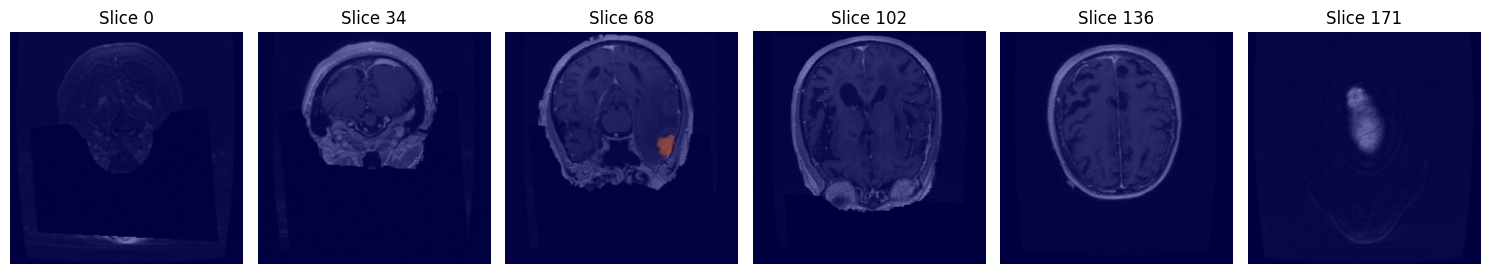

In [4]:
plot_vol_slices(img, mask[0], num_slices=6) 